# Dendrite trace -- Frangi on the pseudo-FDT field

Companion notebook to `02_fdt_blob_mask.ipynb` (soma detection): the
same pseudo-FDT field is fed to a Frangi vesselness filter (Frangi et
al., MICCAI 1998); positive response above a per-image percentile
threshold is the dendrite trace, with the soma mask carved out so the
trace does not bleed into cell bodies.

**Why FDT, not the raw structural channel.** Hessian ridge filters
need a continuous bright line (lambda1 ~ 0, lambda2 << 0). The raw
structural channel is punctate -- the dendrite signal is a chain of
spots, each of which has lambda1 ~ lambda2 << 0 (blob), the wrong
eigenvalue regime. The pseudo-FDT smooths puncta into continuous
bright regions whose ridges genuinely are lines.

**Workflow** mirrors the soma notebook: `DENDRITE_CONFIG` (cell 4),
override cell (cell 8), calibration on one image (cell 10), batch on
N images (cell 12). All pipeline + visualisation functions come from
`synaptic_ssl.pseudolabels.dendrite_frangi`.


## 1. Imports + repo root


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd().resolve()
REPO_ROOT = NB_DIR
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / ".git").is_dir():
    REPO_ROOT = REPO_ROOT.parent
SRC_ROOT = REPO_ROOT / "src"
for p in (SRC_ROOT, REPO_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from synaptic_ssl.pseudolabels import (
    DEFAULT_DENDRITE_CFG,
    DEFAULT_SOMA_CFG,
    run_dendrite_on_image,
    visualise_dendrite_mask,
    resolve_dendrite_cfg,
)

plt.rcParams["figure.dpi"] = 120
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/anokhin/anokhver/thesis


## 2. Configuration

`DENDRITE_CONFIG` is the per-notebook config. Two groups:

- **Data knobs** (`no_patch_root`, `structural_channel`, `file_index`,
  `batch_size`) -- used only by this notebook's load / batch loops.
- **Pipeline overrides** -- override any key of `DEFAULT_DENDRITE_CFG`
  to swap thresholding strategy, scales, etc.

The `cfg=` arg to `run_dendrite_on_image` accepts the same dict; any
key omitted falls through to the module's default.


In [2]:
DENDRITE_CONFIG = dict(
    # ---- Data ----------------------------------------------------------
    no_patch_root="/run/media/anokhin/WinDocuments/anokhver/thesis/data/Microscopy_no_patch/20251030",
    structural_channel=2,
    file_index=1,                  # which .npy (sorted, 0-based)
    batch_size=10,                 # how many images the batch cell processes

    # ---- Soma-side FDT (EDT mode, used for soma extraction) -----------
    # bg_sigma_k=5.0 keeps soma detection clean. The dendrite-side FDT
    # below uses a completely different primitive (Gaussian fuzzy
    # distance instead of EDT*mu) so the two sides do not interfere.
    fdt_compress="log",
    mu_gamma=0.5,
    bg_sigma_k=5.0,
    smooth_sigma=3.0,
    fdt_sigma=5.0,
    support_dilate=0,

    # ---- Dendrite-side FDT ('gaussian' fuzzy distance) ----------------
    # EDT(support)*mu gives ~zero in thin connectors between puncta, so
    # chain-of-dots dendrites stay dotty no matter how much you smooth
    # / close / lower bg. Gaussian mode replaces the EDT primitive with
    # gaussian(mu, sigma=fuzzy_sigma): a continuous bright field
    # wherever ANY pixel within fuzzy_sigma is in the support. Bridges
    # chains of puncta into ridges Frangi can trace.
    #   fuzzy_sigma -- bridging radius in px (~ inter-punctum spacing;
    #                   8-12 px at 107 nm/px is the working range).
    #   bg_sigma_k  -- still useful to pull in dim periphery puncta.
    # G-B (default, recommended): continuous network, balanced noise.
    dend_fdt_cfg=dict(
        fdt_mode="gaussian",
        fuzzy_sigma=10.0,          # ^ longer bridges (more connected, fatter ridges) | v sharper
        bg_sigma_k=4.0,            # ^ stricter (less periphery) | v pulls dimmer trace in
    ),
    # G-A (gentle): less bridging, less fragmentation in dense areas
    #   dend_fdt_cfg=dict(fdt_mode="gaussian", fuzzy_sigma=8.0, bg_sigma_k=4.0),
    # G-C (max recall): catches faintest periphery + thinnest dendrites
    #   dend_fdt_cfg=dict(fdt_mode="gaussian", fuzzy_sigma=10.0, bg_sigma_k=3.5, mu_gamma=0.3),
    # EDT V2 (legacy; chain-of-dots issue; kept for comparison)
    #   dend_fdt_cfg=dict(fdt_mode="edt", support_close=4, support_min_area=30, bg_sigma_k=4.0),

    # ---- Pipeline overrides (None / omitted -> use DEFAULT_DENDRITE_CFG) ----
    frangi_sigmas=(2.5, 3.0, 4.0, 5.0),  # dendrite half-widths in px
    use_hysteresis=True,
    hysteresis_high_pct=88.0,
    hysteresis_low_pct=55.0,
    # Two-stage cleanup: keep CCs >= min_cc_area, then rescue small
    # CCs (>= small_cc_area, < min_cc_area) within small_cc_proximity_px
    # of a big CC. Recovers dim periphery branches that are visually
    # part of the dendrite tree but below the noise-killing area floor.
    min_cc_area=2500,              # px; ^ stricter big-CC floor | v keeps noisier fragments
    small_cc_area=500,             # px; ^ stricter recovery | v rescues smaller branches
    small_cc_proximity_px=20,      # px; ^ rescues farther branches | v stricter neighborhood; 0 = off
    # Edge-of-FOV rescue: CCs touching the image border with size >=
    # border_rescue_min_area are kept regardless of min_cc_area. Catches
    # periphery dendrites clipped by the FOV without lowering the global
    # noise floor. Optional axis-length gate drops blob-shaped rescues.
    border_rescue_min_area=400,    # px; 0 = off; suggest < min_cc_area, e.g. 300-600
    border_rescue_min_axis=30,     # px; 0 = off; demand elongation to reject blob CCs
    # Mirror-pad the FDT by border_pad px before Frangi and crop back.
    # Eliminates the Hessian "corner at the FOV edge" artifact that
    # otherwise suppresses Frangi response within ~sigma_max of the
    # border. Suggest ~ 3 * max(frangi_sigmas).
    border_pad=15,                 # px; 0 = off
    # Skeleton-spur pruning: removes short lateral branches off real
    # dendrites. Length floor in skeleton px (~px = 0.1 um at 107 nm/px).
    # 0 = off. 30-60 px removes spines + short noise spurs; >=80 only
    # keeps major branches.
    spur_prune_px=0,               # px; 0 = off; suggest 30-60 to remove spurs
    closing_radius=4,
    # frangi_alpha=0.5,
    # frangi_beta=0.5,
    # threshold_pct=50.0,            # only used when use_hysteresis=False
    # soma_buffer_dilate=5,
    # dilate_r=0,
)

print("DEFAULT_DENDRITE_CFG (active unless overridden):")
for k in ("frangi_sigmas", "threshold_pct", "use_hysteresis",
          "soma_buffer_dilate", "min_cc_area", "closing_radius"):
    print(f"  {k:22s} = {DEFAULT_DENDRITE_CFG[k]!r}")
print()
print("DEFAULT_SOMA_CFG (used for carving):")
for k in ("blob_threshold_method", "blob_fdt_pct", "min_solidity", "shape_mode"):
    print(f"  {k:22s} = {DEFAULT_SOMA_CFG[k]!r}")

DEFAULT_DENDRITE_CFG (active unless overridden):
  frangi_sigmas          = (1.0, 1.5, 2.0, 3.0, 4.0)
  threshold_pct          = 50.0
  use_hysteresis         = False
  soma_buffer_dilate     = 5
  min_cc_area            = 100
  closing_radius         = 2

DEFAULT_SOMA_CFG (used for carving):
  blob_threshold_method  = 'percentile'
  blob_fdt_pct           = 95.0
  min_solidity           = 0.4
  shape_mode             = 'closing'


## 3. Helpers

`list_images(cfg)` -- sorted `.npy` list from `no_patch_root`. The
pipeline-cfg part of `DENDRITE_CONFIG` is selected with `_pipeline_cfg`
so the `cfg=` arg to `run_dendrite_on_image` never carries data keys.


In [3]:
_DATA_KEYS = {"no_patch_root", "structural_channel", "file_index", "batch_size"}
# Soma-side FDT enhancements: routed via soma_cfg=... .
_FDT_KEYS = {
    "fdt_compress", "mu_gamma", "support_dilate", "fdt_sigma",
    "bg_sigma_k", "smooth_sigma",
    "fdt_mode", "fuzzy_sigma", "support_close", "support_min_area",
}
# Nested dict: dendrite-side FDT overrides routed via dend_fdt_cfg=... .
_NESTED_KEYS = {"dend_fdt_cfg"}


def _pipeline_cfg(cfg):
    """Pipeline overrides (Frangi + threshold + cleanup) for dendrite module."""
    return {k: v for k, v in cfg.items()
            if k not in _DATA_KEYS and k not in _FDT_KEYS and k not in _NESTED_KEYS}


def _soma_cfg(cfg):
    """FDT-enhancement overrides; passed as soma_cfg to run_dendrite_on_image."""
    return {k: v for k, v in cfg.items() if k in _FDT_KEYS}


def _dend_fdt_cfg(cfg):
    """Dendrite-side FDT overrides (applied on top of soma_cfg)."""
    return cfg.get("dend_fdt_cfg")


## 4. Overrides for the calibration run

Tune knobs here without scrolling back to cell 4. Inline `^/v` notes
indicate direction of effect. The pipeline calls `_pipeline_cfg(cfg)`
which drops data keys, so it is safe to put both kinds in
`DENDRITE_CONFIG.update(...)`.


In [4]:
# Uncomment any line to override the DENDRITE_CONFIG default for this run.
DENDRITE_CONFIG.update(
    # file_index=0,                  # which .npy in the folder (sorted, 0-based)

    # ---- Dendrite single-dial knobs (bubble logic below routes them
    #       into dend_fdt_cfg so the soma side stays untouched) --------
    fuzzy_sigma=14.0,                # ^ longer bridges (dim chains connected) | v sharper, less noise
    #                                # prev=12.0; derived: bridges chains up to ~28 px = 3.0 um gaps
    # dend_mu_gamma=0.5,             # ^ 1.0 = off | v asymmetric dim boost on dend side only
    spur_prune_px=40,                # ^ kills longer side branches (~4 um) | v keeps more spurs; 0 = off

    # ---- Soma-side FDT (EDT mode, passed as soma_cfg) -----------------
    # fdt_compress="log",            # 'linear' | 'sqrt' | 'log'
    mu_gamma=0.3,                    # affects BOTH soma+dend via merge (unless dend_mu_gamma set above)
    # bg_sigma_k=5.0,                # ^ stricter cutoff | v keeps dim trace (affects somas too)
    # smooth_sigma=3.0,
    # fdt_sigma=5.0,
    # support_dilate=0,

    # ---- Dendrite-side FDT (mode/bg fixed; tune fuzzy_sigma above) ---
    # G-A gentle | G-B recommended | G-C max recall -- see cell 4 for alts
    dend_fdt_cfg=dict(fdt_mode="gaussian", bg_sigma_k=4.0),

    # ---- Frangi vesselness --------------------------------------------
    frangi_sigmas=(2.0, 3.0, 4.5, 7.0),       # geometric (ratio ~1.5); matches FDT-broadened ridges
    # frangi_sigmas=(2.0, 2.5, 3.0, 4.0, 5.0),  # prev: oversampled small scales -> spur-prone
    border_pad=21,                            # 3 * max(sigma); prev=15 (default for cell-4 sigmas)
    frangi_alpha=0.5,                          # 0.5 default | v stricter line preference, drops blob clutter
    # frangi_beta=0.5,

    # ---- Threshold on Frangi response ---------------------------------
    # use_hysteresis=True,
    # hysteresis_high_pct=88.0,                # KEEP high seed strict -- noise won't seed
    hysteresis_low_pct=50.0,                   # literature default (Soares 2006); prev=45.0
    # threshold_pct=70.0,                      # only used when use_hysteresis=False

    # ---- Soma carving + cleanup ---------------------------------------
    # soma_buffer_dilate=5,
    # min_cc_area=2500,                        # KEEP -- noise floor for isolated CCs
    small_cc_area=300,                         # 500 -> 300: rescues smaller dim fragments (proximity-gated, noise-safe)
    small_cc_proximity_px=30,                  # px; ^ rescues farther branches | v stricter neighborhood
    # ---- Edge-of-FOV rescue (active values from cell 4) --------------
    # border_rescue_min_area=400,
    # border_rescue_min_axis=30,
    # border_pad=15,
    # closing_radius=4,
    # dilate_r=0,
)

# Bubble single-dial dendrite knobs into dend_fdt_cfg so the soma side
# stays clean and the top-level value wins over any nested one.
_DEND_SINGLE = {"fuzzy_sigma": "fuzzy_sigma", "dend_mu_gamma": "mu_gamma"}
_dend_extra = {
    target: DENDRITE_CONFIG.pop(src) for src, target in _DEND_SINGLE.items()
    if src in DENDRITE_CONFIG
}
if _dend_extra:
    DENDRITE_CONFIG["dend_fdt_cfg"] = {
        **(DENDRITE_CONFIG.get("dend_fdt_cfg") or {}),
        **_dend_extra,
    }

_r = resolve_dendrite_cfg(_pipeline_cfg(DENDRITE_CONFIG))
_sc = _soma_cfg(DENDRITE_CONFIG)
_dc = _dend_fdt_cfg(DENDRITE_CONFIG) or {}
print(
    "Soma-side FDT (soma_cfg):  "
    + f"fdt_mode={_sc.get('fdt_mode', 'edt')!r}  "
    + f"fdt_compress={_sc.get('fdt_compress', 'linear')!r}  "
    + f"mu_gamma={_sc.get('mu_gamma', 1.0)}  "
    + f"bg_sigma_k={_sc.get('bg_sigma_k', 3.0)}  "
    + f"fdt_sigma={_sc.get('fdt_sigma', 0.0)}"
)
print(
    "Dendrite-side FDT overrides:  "
    + (", ".join(f"{k}={v}" for k, v in _dc.items()) if _dc else "(none)")
    + f"  | fuzzy_sigma={_dc.get('fuzzy_sigma', '(default)')}"
)
print(
    f"file_index         = {DENDRITE_CONFIG['file_index']}\n"
    f"frangi_sigmas      = {_r['frangi_sigmas']}\n"
    f"frangi             : alpha={_r['frangi_alpha']}  beta={_r['frangi_beta']}\n"
    f"thresholding       = "
    + (f"hysteresis high=p{_r['hysteresis_high_pct']} low=p{_r['hysteresis_low_pct']}"
       if _r['use_hysteresis']
       else f"percentile p{_r['threshold_pct']}")
    + "\n"
    f"soma_buffer_dilate = {_r['soma_buffer_dilate']} px  "
    f"min_cc_area={_r['min_cc_area']} px  "
    f"closing_radius={_r['closing_radius']}  "
    f"dilate_r={_r['dilate_r']}\n"
    f"border_pad={_r['border_pad']} px  "
    f"border_rescue: min_area={_r['border_rescue_min_area']} px  "
    f"min_axis={_r['border_rescue_min_axis']} px\n"
    f"spur_prune_px={_r['spur_prune_px']} px"
)

Soma-side FDT (soma_cfg):  fdt_mode='edt'  fdt_compress='log'  mu_gamma=0.3  bg_sigma_k=5.0  fdt_sigma=5.0
Dendrite-side FDT overrides:  fdt_mode=gaussian, bg_sigma_k=4.0, fuzzy_sigma=14.0  | fuzzy_sigma=14.0
file_index         = 1
frangi_sigmas      = (2.0, 3.0, 4.5, 7.0)
frangi             : alpha=0.5  beta=0.5
thresholding       = hysteresis high=p88.0 low=p50.0
soma_buffer_dilate = 5 px  min_cc_area=2500 px  closing_radius=4  dilate_r=0
border_pad=21 px  border_rescue: min_area=400 px  min_axis=30 px
spur_prune_px=40 px


## 5. Calibration -- one image

Tune `DENDRITE_CONFIG` (cell 4) or cell 8 (overrides), then re-run
this cell. The red trace should follow every visible dendrite without
bleeding into the cyan-outlined soma zones.

Cost: ~15-20 s for the soma run + FDT + Frangi at default sigmas.


[1/67] 2_2_PSI_3010_Multichannel Z-Stack_20251030_51.npy
  time=187.4s
  somas: n=30  cov=4.53%
  Frangi threshold (hysteresis) = 0.0192
  dendrite trace: n_cc=123  cov=7.98%


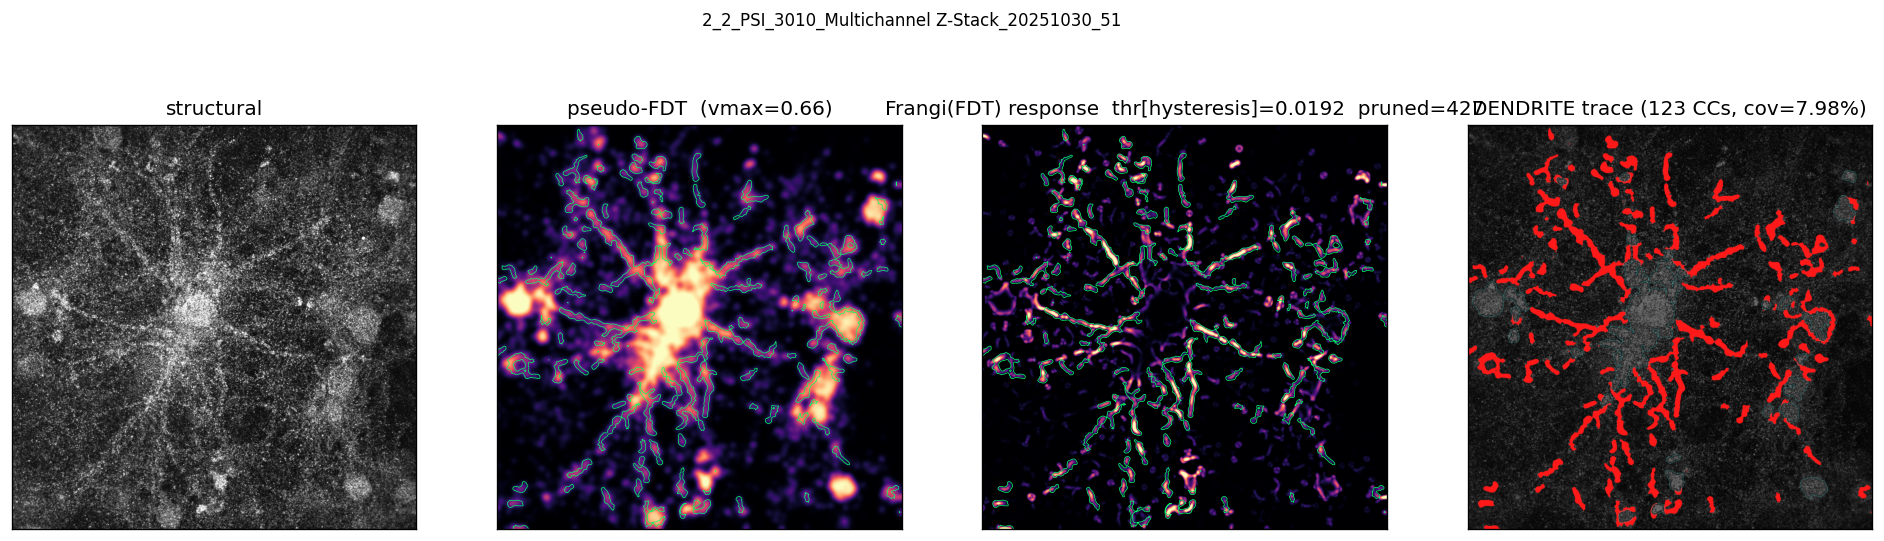

In [5]:
import time

_files = sorted(Path(DENDRITE_CONFIG["no_patch_root"]).glob("*.npy"))
if not _files:
    raise FileNotFoundError(f"no .npy MIPs found under {DENDRITE_CONFIG['no_patch_root']}")
_path = _files[DENDRITE_CONFIG["file_index"]]
print(f"[{DENDRITE_CONFIG['file_index']}/{len(_files)-1}] {_path.name}")

_t0 = time.time()
_struct, _fdt, _soma, _dend = run_dendrite_on_image(
    _path,
    cfg=_pipeline_cfg(DENDRITE_CONFIG),
    soma_cfg=_soma_cfg(DENDRITE_CONFIG),
    dend_fdt_cfg=_dend_fdt_cfg(DENDRITE_CONFIG),
    structural_channel=DENDRITE_CONFIG["structural_channel"],
)
_dt = time.time() - _t0
print(
    f"  time={_dt:.1f}s\n"
    f"  somas: n={_soma['n_blobs']}  cov={_soma['mask'].mean():.2%}\n"
    f"  Frangi threshold ({_dend['threshold_kind']}) = {_dend['threshold']:.4f}\n"
    f"  dendrite trace: n_cc={_dend['n_trace_cc']}  cov={_dend['trace'].mean():.2%}"
)
fig, _ = visualise_dendrite_mask(
    _struct, _fdt, _soma, _dend,
    cfg=_pipeline_cfg(DENDRITE_CONFIG),
)
fig.suptitle(_path.stem[:60], y=1.02, fontsize=10)
plt.show()


## 6. Batch -- N images with the calibrated `DENDRITE_CONFIG`

Runs the same config on the first `batch_size` images. Each image is
~15-20 s, so a 10-image batch is ~3 minutes.


In [ ]:
import time

_files = sorted(Path(DENDRITE_CONFIG["no_patch_root"]).glob("*.npy"))
if not _files:
    raise FileNotFoundError(f"no .npy MIPs found under {DENDRITE_CONFIG['no_patch_root']}")
_batch = _files[4 : 4 +int(DENDRITE_CONFIG["batch_size"])]
print(f"dendrite batch: {len(_batch)} images")

fig, axes_grid = plt.subplots(len(_batch), 4, figsize=(20, 5 * len(_batch)))
if len(_batch) == 1:
    axes_grid = np.atleast_2d(axes_grid)

_t0 = time.time()
_stats = []
for i, path in enumerate(_batch):
    _ti = time.time()
    structural, fdt_info, soma_info, dend_info = run_dendrite_on_image(
        path,
        cfg=_pipeline_cfg(DENDRITE_CONFIG),
        soma_cfg=_soma_cfg(DENDRITE_CONFIG),
        dend_fdt_cfg=_dend_fdt_cfg(DENDRITE_CONFIG),
        structural_channel=DENDRITE_CONFIG["structural_channel"],
    )
    visualise_dendrite_mask(
        structural, fdt_info, soma_info, dend_info,
        cfg=_pipeline_cfg(DENDRITE_CONFIG),
        axes=axes_grid[i], title_prefix=f"[{i}] ",
    )
    axes_grid[i, 0].set_title(f"[{i}] {path.stem[:30]}\u2026")
    _stats.append(dict(
        idx=i, name=path.name,
        n_somas=soma_info["n_blobs"],
        n_trace_cc=dend_info["n_trace_cc"],
        trace_cov=float(dend_info["trace"].mean()),
        thr=dend_info["threshold"],
        sec=time.time() - _ti,
    ))
    print(f"  [{i:2d}] {path.name[:50]:50s}  "
          f"somas={soma_info['n_blobs']:3d}  "
          f"trace_cov={dend_info['trace'].mean():.2%}  "
          f"thr={dend_info['threshold']:.4f}  "
          f"{_stats[-1]['sec']:.1f}s")
plt.tight_layout()
plt.show()

_co = [s["trace_cov"] for s in _stats]
_nc = [s["n_trace_cc"] for s in _stats]
print(
    f"\nDENDRITE batch summary: n={len(_stats)}  "
    f"cov mean={np.mean(_co):.2%}  median={np.median(_co):.2%}  "
    f"min={np.min(_co):.2%}  max={np.max(_co):.2%}\n"
    f"  n_trace_cc: mean={np.mean(_nc):.0f}  median={np.median(_nc):.0f}  "
    f"min={np.min(_nc):.0f}  max={np.max(_nc):.0f}  "
    f"total_time={time.time()-_t0:.1f}s"
)


dendrite batch: 10 images
